In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [5]:
def find_project_root(start=None):
    current = Path.cwd() if start is None else Path(start)
    for path in [current, *current.parents]:
        if (path / "Data").exists():
            return path
    raise FileNotFoundError("Could not find project root containing Data/")


PROJECT_ROOT = find_project_root()
BASE_DIR = PROJECT_ROOT
DATA_DIR = PROJECT_ROOT / "Data"
DATA_FILE = DATA_DIR / "rides_data_without_discontinuities.parquet"


In [6]:
dur_dist_data = pd.read_parquet(DATA_FILE)
dur_dist_data["duration_min_bin"] = (
    np.floor(dur_dist_data["total_duration_minutes"])
)

dur_dist_data.head()

,bike_id,bike_model,end_date,end_lat,end_lon,end_station_id,end_station_name,speed_km_per_h,start_date,start_day_of_week,...,start_station_id,start_station_name,straight_line_distance_km,total_duration,total_duration_minutes,trip_id,previous_end_station_id,previous_end_date,previous_end_station_name,duration_min_bin
0,2.0,CLASSIC,2024-08-01 08:26:00,51.500744,-0.202759,1115.0,"Ilchester Place, Kensington",11.269322,2024-08-01 08:12:00,Thursday,...,200029,"Finlay Street, Fulham",2.804527,14m 55s,14.931833,141622479,NaN,NaT,None,14.0
1,2.0,CLASSIC,2024-08-01 13:43:00,51.494224,-0.236770,300037.0,"Ravenscourt Park Station, Hammersmith",8.507715,2024-08-01 13:26:00,Thursday,...,1115,"Ilchester Place, Kensington",2.463470,17m 22s,17.373433,141631864,1115.0,2024-08-01 08:26:00,"Ilchester Place, Kensington",17.0
2,2.0,CLASSIC,2024-08-03 12:37:00,51.494499,-0.228188,200166.0,"Southerton Road, Hammersmith",11.829568,2024-08-03 12:34:00,Saturday,...,300037,"Ravenscourt Park Station, Hammersmith",0.594909,3m 1s,3.017400,141687538,300037.0,2024-08-01 13:43:00,"Ravenscourt Park Station, Hammersmith",3.0
3,2.0,CLASSIC,2024-08-05 08:58:00,51.514767,-0.225787,200136.0,"BBC White City, White City",9.351433,2024-08-05 08:43:00,Monday,...,200166,"Southerton Road, Hammersmith",2.259820,14m 29s,14.499300,141741326,200166.0,2024-08-03 12:37:00,"Southerton Road, Hammersmith",14.0
4,2.0,CLASSIC,2024-09-05 13:15:00,51.514771,-0.122220,1007.0,"Drury Lane, Covent Garden",6.669502,2024-09-05 12:53:00,Thursday,...,1201,"Bank of England Museum, Bank",2.396771,21m 33s,21.561767,142641262,1201.0,2024-09-05 12:00:00,"Bank of England Museum, Bank",21.0


In [7]:
dur_dist_data["duration_counts"] = (
    dur_dist_data["duration_min_bin"]
    .value_counts()
    .sort_index()
)

In [8]:
dur_dist_data_weekends = dur_dist_data[dur_dist_data["start_day_of_week"].isin(["Saturday", "Sunday"])]
dur_dist_data_weekdays = dur_dist_data[dur_dist_data["start_day_of_week"].isin(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"])]

dur_dist_data_weekends.head()

,bike_id,bike_model,end_date,end_lat,end_lon,end_station_id,end_station_name,speed_km_per_h,start_date,start_day_of_week,...,start_station_name,straight_line_distance_km,total_duration,total_duration_minutes,trip_id,previous_end_station_id,previous_end_date,previous_end_station_name,duration_min_bin,duration_counts
2,2.0,CLASSIC,2024-08-03 12:37:00,51.494499,-0.228188,200166.0,"Southerton Road, Hammersmith",11.829568,2024-08-03 12:34:00,Saturday,...,"Ravenscourt Park Station, Hammersmith",0.594909,3m 1s,3.017400,141687538,300037.0,2024-08-01 13:43:00,"Ravenscourt Park Station, Hammersmith",3.0,379967.0
18,2.0,CLASSIC,2024-09-07 17:29:00,51.518908,-0.079249,1161.0,"Brushfield Street, Liverpool Street",7.512019,2024-09-07 17:12:00,Saturday,...,"Aylward Street, Stepney",2.119975,16m 55s,16.932667,142698443,300049.0,2024-09-07 16:28:00,"Aylward Street, Stepney",16.0,445810.0
19,2.0,CLASSIC,2024-09-07 18:42:00,51.525615,-0.088533,1064.0,"Old Street Station, St. Luke's",10.194316,2024-09-07 18:36:00,Saturday,...,"Brushfield Street, Liverpool Street",0.984250,5m 47s,5.792933,142701280,1161.0,2024-09-07 17:29:00,"Brushfield Street, Liverpool Street",5.0,412301.0
20,2.0,CLASSIC,2024-09-07 20:13:00,51.519181,-0.140486,3494.0,"Foley Street, Fitzrovia",10.473168,2024-09-07 19:52:00,Saturday,...,"Old Street Station, St. Luke's",3.664945,20m 59s,20.996200,142703267,1064.0,2024-09-07 18:42:00,"Old Street Station, St. Luke's",20.0,380785.0
26,2.0,CLASSIC,2024-09-08 17:47:00,51.522892,-0.171682,10625.0,"Penfold Street, Marylebone",10.892817,2024-09-08 17:30:00,Sunday,...,"Moor Street, Soho",3.059114,16m 51s,16.850267,142723288,3504.0,2024-09-08 11:50:00,"Moor Street, Soho",16.0,228178.0


In [9]:
dur_dist_data["total_duration_minutes"].quantile(
    [0.05, 0.5, 0.9, 0.95, 0.99, 0.999, 0.9999, 1.0]
)

0.0500         3.267000
0.5000        13.142767
0.9000        31.567210
0.9500        41.687872
0.9900        85.369115
0.9990       810.130412
0.9999     13230.105307
1.0000    270479.204233
Name: total_duration_minutes, dtype: float64

In [10]:
lower_limit = 3
upper_limit = 180

mask = (
    (dur_dist_data["total_duration_minutes"] >= lower_limit) &
    (dur_dist_data["total_duration_minutes"] <= upper_limit)
)

covered_count = mask.sum()
total_count = len(dur_dist_data)

covered_percent = covered_count / total_count * 100

print(f"Liczba przejazdów w zakresie {lower_limit}-{upper_limit} min: {covered_count}")
print(f"Liczba wszystkich przejazdów: {total_count}")
print(f"Udział danych w tym zakresie: {covered_percent:.2f}%")

Liczba przejazdów w zakresie 3-180 min: 15377692
Liczba wszystkich przejazdów: 16091818
Udział danych w tym zakresie: 95.56%


In [11]:
# ---------- Min and max duration by day type ----------

print("Weekdays")
print("Min duration [min]:", dur_dist_data_weekdays["total_duration_minutes"].min())
print("Max duration [min]:", dur_dist_data_weekdays["total_duration_minutes"].max())

print("---------------------------------")

print("Weekends")
print("Min duration [min]:", dur_dist_data_weekends["total_duration_minutes"].min())
print("Max duration [min]:", dur_dist_data_weekends["total_duration_minutes"].max())

Weekdays
Min duration [min]: 0.003266666666666667
Max duration [min]: 270479.20423333335
---------------------------------
Weekends
Min duration [min]: 0.007033333333333333
Max duration [min]: 204284.97561666666


In [12]:
# ---------- Counting rides by duration ----------

duration_counts_weekdays = (
    dur_dist_data_weekdays.loc[
        dur_dist_data_weekdays["total_duration_minutes"].between(lower_limit, upper_limit),
        "duration_min_bin"
    ]
    .value_counts()
    .sort_index()
)

duration_counts_weekends = (
    dur_dist_data_weekends.loc[
        dur_dist_data_weekends["total_duration_minutes"].between(lower_limit, upper_limit),
        "duration_min_bin"
    ]
    .value_counts()
    .sort_index()
)

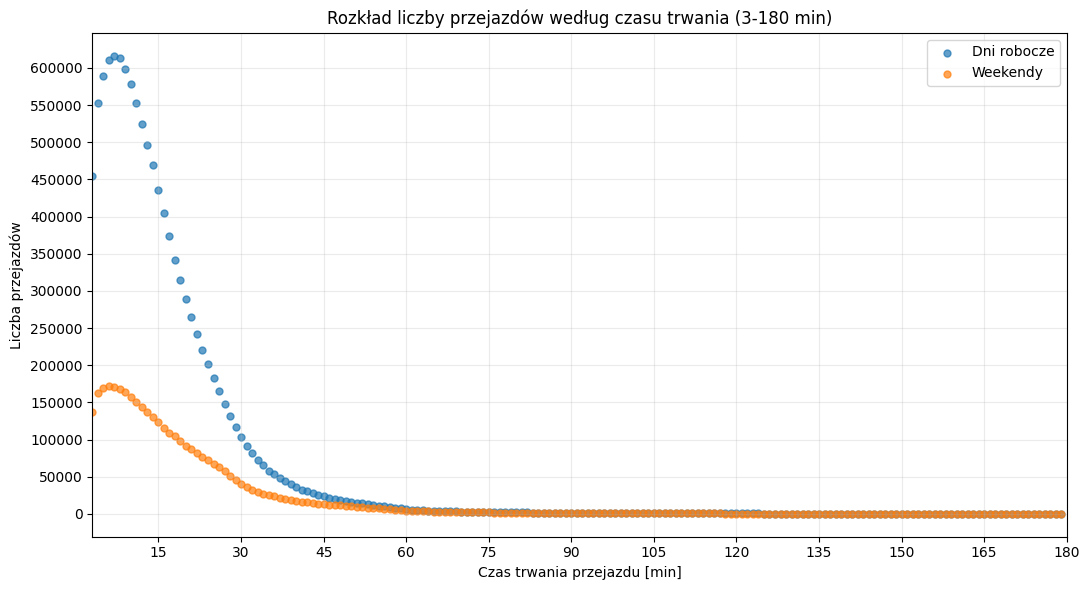

In [13]:
# ---------- Duration counts: weekdays vs weekends ----------

plt.figure(figsize=(11, 6))

plt.scatter(
    duration_counts_weekdays.index,
    duration_counts_weekdays.values,
    s=25,
    alpha=0.7,
    label="Dni robocze"
)

plt.scatter(
    duration_counts_weekends.index,
    duration_counts_weekends.values,
    s=25,
    alpha=0.7,
    label="Weekendy"
)

plt.xlabel("Czas trwania przejazdu [min]")
plt.ylabel("Liczba przejazdów")
plt.title(f"Rozkład liczby przejazdów według czasu trwania ({lower_limit}-{upper_limit} min)")

plt.legend()
plt.grid(alpha=0.25)

plt.xlim(lower_limit, upper_limit)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(15))
plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(15))

plt.tight_layout()
plt.show()

# 1.Histograms

In [14]:
# ---------- Preparing duration data ----------

duration_weekdays = dur_dist_data_weekdays.loc[
    dur_dist_data_weekdays["total_duration_minutes"].between(lower_limit, upper_limit),
    "total_duration_minutes"
]

duration_weekends = dur_dist_data_weekends.loc[
    dur_dist_data_weekends["total_duration_minutes"].between(lower_limit, upper_limit),
    "total_duration_minutes"
]


# ---------- Common range ----------

min_time = lower_limit
max_time = upper_limit

# ---------- Logarithmic bin edges ----------

def make_log_bin_edges(min_value, max_value, a):
    bin_edges = [min_value]

    while bin_edges[-1] < max_value:
        next_edge = bin_edges[-1] * a
        bin_edges.append(min(next_edge, max_value))

    return np.array(bin_edges)

# ---------- Logarithmic binning ----------

def log_binning(data, bin_edges):

    counts, edges = np.histogram(data, bins=bin_edges)

    widths = edges[1:] - edges[:-1]

    probability_density = counts / (len(data) * widths)

    bin_centers = np.sqrt(edges[:-1] * edges[1:])

    mask = probability_density > 0

    return (
        bin_centers[mask],
        probability_density[mask],
        counts[mask],
        edges
    )
# ---------- Calculating results for different a values ----------

a_values = [1.5, 1.75, 2]

results = {}

for a_value in a_values:

    bin_edges = make_log_bin_edges(
        min_time,
        max_time,
        a_value
    )

    x_weekdays, p_weekdays, n_weekdays, edges = log_binning(
        duration_weekdays,
        bin_edges
    )

    x_weekends, p_weekends, n_weekends, edges = log_binning(
        duration_weekends,
        bin_edges
    )

    results[a_value] = {
        "weekdays": {
            "x": x_weekdays,
            "p": p_weekdays,
            "n": n_weekdays
        },
        "weekends": {
            "x": x_weekends,
            "p": p_weekends,
            "n": n_weekends
        },
        "bin_edges": bin_edges
    }

    print(f"\na = {a_value}")
    print("Number of bins:", len(bin_edges) - 1)
    print("First bin edges:", bin_edges[:5])
    print("Last bin edges:", bin_edges[-5:])


a = 1.5
Number of bins: 11
First bin edges: [ 3.      4.5     6.75   10.125  15.1875]
Last bin edges: [ 51.2578125   76.88671875 115.33007812 172.99511719 180.        ]

a = 1.75
Number of bins: 8
First bin edges: [ 3.          5.25        9.1875     16.078125   28.13671875]
Last bin edges: [ 28.13671875  49.23925781  86.16870117 150.79522705 180.        ]

a = 2
Number of bins: 6
First bin edges: [ 3  6 12 24 48]
Last bin edges: [ 12  24  48  96 180]


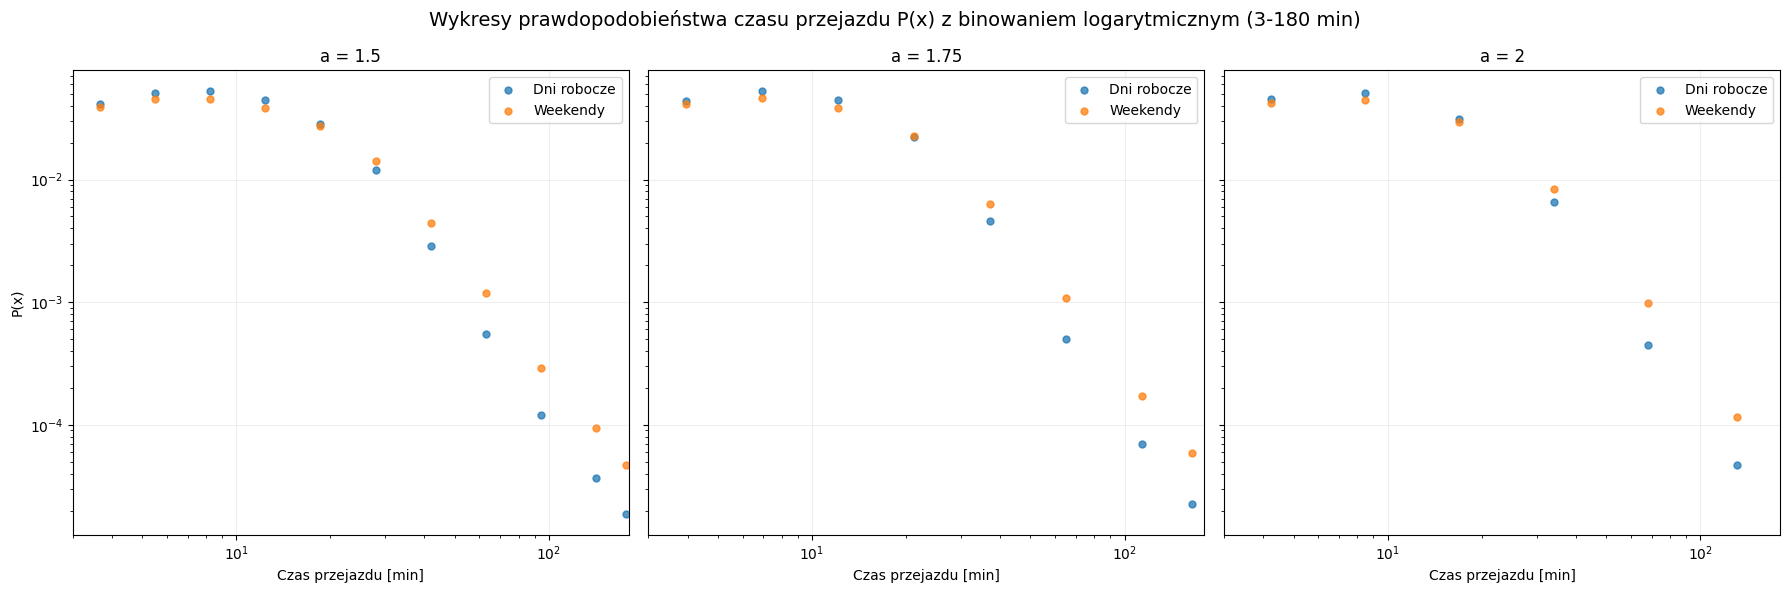

In [15]:
# ---------- Plotting logarithmic probability density ----------

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

colors = {
    "Dni robocze": "#1F77B4",
    "Weekendy": "#FF7F0E"
}

for ax, a_value in zip(axes, a_values):

    ax.scatter(
        results[a_value]["weekdays"]["x"],
        results[a_value]["weekdays"]["p"],
        s=25,
        alpha=0.75,
        color=colors["Dni robocze"],
        label="Dni robocze"
    )

    ax.scatter(
        results[a_value]["weekends"]["x"],
        results[a_value]["weekends"]["p"],
        s=25,
        alpha=0.75,
        color=colors["Weekendy"],
        label="Weekendy"
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(lower_limit, upper_limit)

    ax.set_xlabel("Czas przejazdu [min]")
    ax.set_title(f"a = {a_value}")

    ax.grid(True, axis="y", alpha=0.2, which="major")
    ax.grid(True, axis="x", alpha=0.2, which="major")    
    ax.legend()

axes[0].set_ylabel("P(x)")

fig.suptitle(
    f"Wykresy prawdopodobieństwa czasu przejazdu P(x) z binowaniem logarytmicznym ({lower_limit}-{upper_limit} min)",
    fontsize=14
)

plt.tight_layout()
plt.show()

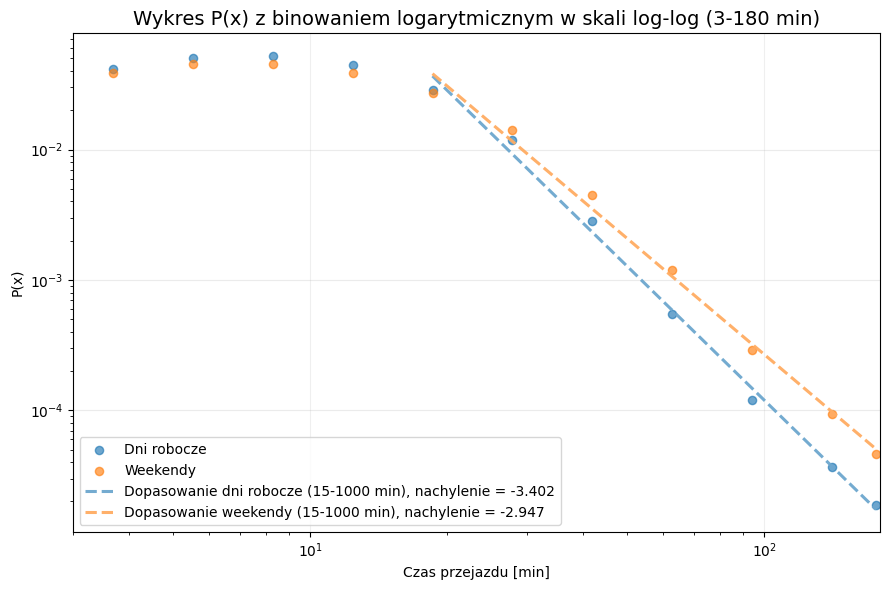

Zakres dopasowania:
x_min = 15
x_max = 1000

Dni robocze:
Nachylenie = -3.402
Wyraz wolny = 2.884

Weekendy:
Nachylenie = -2.947
Wyraz wolny = 2.324


In [16]:
# ---------- Separate tail fits for weekdays and weekends ----------

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


a_value = 1.5

x_weekdays = results[a_value]["weekdays"]["x"]
y_weekdays = results[a_value]["weekdays"]["p"]

x_weekends = results[a_value]["weekends"]["x"]
y_weekends = results[a_value]["weekends"]["p"]


# ---------- Fitting range ----------

x_min = 15
x_max = 1000


# ---------- Helper function for lighter colors ----------

def lighten_color(color, amount=0.45):
    c = np.array(mcolors.to_rgb(color))
    white = np.array([1, 1, 1])
    return tuple(c + (white - c) * amount)


# ---------- Colors ----------

colors = {
    "Dni robocze": "#1F77B4",
    "Weekendy": "#FF7F0E"
}

fit_colors = {
    "Dni robocze": lighten_color(colors["Dni robocze"], amount=0.35),
    "Weekendy": lighten_color(colors["Weekendy"], amount=0.35)
}


# ---------- Fit mask: weekdays ----------

fit_mask_weekdays = (
    (x_weekdays > 0) &
    (y_weekdays > 0) &
    (x_weekdays >= x_min) &
    (x_weekdays <= x_max)
)

x_fit_data_weekdays = x_weekdays[fit_mask_weekdays]
y_fit_data_weekdays = y_weekdays[fit_mask_weekdays]


# ---------- Fit mask: weekends ----------

fit_mask_weekends = (
    (x_weekends > 0) &
    (y_weekends > 0) &
    (x_weekends >= x_min) &
    (x_weekends <= x_max)
)

x_fit_data_weekends = x_weekends[fit_mask_weekends]
y_fit_data_weekends = y_weekends[fit_mask_weekends]


# ---------- Log-log fit: weekdays ----------

log_x_weekdays = np.log10(x_fit_data_weekdays)
log_y_weekdays = np.log10(y_fit_data_weekdays)

slope_weekdays, intercept_weekdays = np.polyfit(log_x_weekdays, log_y_weekdays, 1)


# ---------- Log-log fit: weekends ----------

log_x_weekends = np.log10(x_fit_data_weekends)
log_y_weekends = np.log10(y_fit_data_weekends)

slope_weekends, intercept_weekends = np.polyfit(log_x_weekends, log_y_weekends, 1)


# ---------- Fitted lines ----------

x_fit_weekdays = np.logspace(
    np.log10(x_fit_data_weekdays.min()),
    np.log10(x_fit_data_weekdays.max()),
    200
)

y_fit_weekdays = 10**intercept_weekdays * x_fit_weekdays**slope_weekdays


x_fit_weekends = np.logspace(
    np.log10(x_fit_data_weekends.min()),
    np.log10(x_fit_data_weekends.max()),
    200
)

y_fit_weekends = 10**intercept_weekends * x_fit_weekends**slope_weekends


# ---------- Plot ----------

plt.figure(figsize=(9, 6))


# all points: weekdays
plt.scatter(
    x_weekdays,
    y_weekdays,
    s=35,
    alpha=0.65,
    color=colors["Dni robocze"],
    label="Dni robocze"
)

# all points: weekends
plt.scatter(
    x_weekends,
    y_weekends,
    s=35,
    alpha=0.65,
    color=colors["Weekendy"],
    label="Weekendy"
)


# fitted line: weekdays
plt.plot(
    x_fit_weekdays,
    y_fit_weekdays,
    color=fit_colors["Dni robocze"],
    linestyle="--",
    linewidth=2.2,
    alpha=0.95,
    label=f"Dopasowanie dni robocze ({x_min}-{x_max} min), nachylenie = {slope_weekdays:.3f}"
)

# fitted line: weekends
plt.plot(
    x_fit_weekends,
    y_fit_weekends,
    color=fit_colors["Weekendy"],
    linestyle="--",
    linewidth=2.2,
    alpha=0.95,
    label=f"Dopasowanie weekendy ({x_min}-{x_max} min), nachylenie = {slope_weekends:.3f}"
)


# ---------- Scales and labels ----------

plt.xscale("log")
plt.yscale("log")
plt.xlim(lower_limit, upper_limit)

plt.xlabel("Czas przejazdu [min]")
plt.ylabel("P(x)")

plt.title(
    f"Wykres P(x) z binowaniem logarytmicznym w skali log-log ({lower_limit}-{upper_limit} min)",
    fontsize=14
)

plt.grid(True, axis="y", alpha=0.25, which="major")
plt.grid(True, axis="x", alpha=0.20, which="major")

plt.legend()
plt.tight_layout()
plt.show()


# ---------- Results ----------

print("Zakres dopasowania:")
print(f"x_min = {x_min}")
print(f"x_max = {x_max}")
print()

print("Dni robocze:")
print(f"Nachylenie = {slope_weekdays:.3f}")
print(f"Wyraz wolny = {intercept_weekdays:.3f}")
print()

print("Weekendy:")
print(f"Nachylenie = {slope_weekends:.3f}")
print(f"Wyraz wolny = {intercept_weekends:.3f}")

# Histogram prędkości

# Odległość przejazdów w linii prostej

In [17]:
# ---------- Straight-line distance between start and end stations ----------

# This column is prepared in data_preparation.ipynb.
distance_columns = [
    "trip_id",
    "start_date",
    "end_date",
    "total_duration_minutes",
    "start_lat",
    "start_lon",
    "end_lat",
    "end_lon",
    "straight_line_distance_km",
]

ride_distance_data = dur_dist_data[distance_columns].copy()
coordinate_columns = ["start_lat", "start_lon", "end_lat", "end_lon"]
missing_coordinates_count = ride_distance_data[coordinate_columns].isna().any(axis=1).sum()

print(f"Liczba przejazdów: {len(ride_distance_data)}")
print(f"Liczba przejazdów z brakującymi współrzędnymi: {missing_coordinates_count}")

display(
    ride_distance_data["straight_line_distance_km"].describe(
        percentiles=[0.05, 0.5, 0.9, 0.95, 0.99]
    )
)

display(
    ride_distance_data
    .sort_values("straight_line_distance_km", ascending=False)
    .head()
)



Liczba przejazdów: 16091818
Liczba przejazdów z brakującymi współrzędnymi: 0


count    1.609182e+07
mean     2.376724e+00
std      1.738575e+00
min      0.000000e+00
5%       3.420790e-01
50%      1.982218e+00
90%      4.703861e+00
95%      5.775892e+00
99%      8.088740e+00
max      1.696891e+01
Name: straight_line_distance_km, dtype: float64

,trip_id,start_date,end_date,total_duration_minutes,start_lat,start_lon,end_lat,end_lon,straight_line_distance_km
580061,137489640,2024-02-24 12:20:00,2024-02-24 14:06:00,105.405000,51.546326,-0.009935,51.463211,-0.215551,16.968915
12925974,137489653,2024-02-24 12:20:00,2024-02-24 14:06:00,105.153683,51.546326,-0.009935,51.463211,-0.215551,16.968915
14052822,140275736,2024-06-17 18:35:00,2024-06-17 19:40:00,65.797917,51.464786,-0.215619,51.541793,-0.004810,16.918216
13731906,140191949,2024-06-14 15:26:00,2024-06-14 16:26:00,60.530150,51.494224,-0.236770,51.541793,-0.004810,16.899189
14424928,140049573,2024-06-09 13:37:00,2024-06-09 14:44:00,67.649733,51.494224,-0.236770,51.541793,-0.004810,16.899189


In [18]:
# straight_line_distance_km is already present in dur_dist_data from data_preparation.ipynb.
dur_dist_data[["trip_id", "straight_line_distance_km"]].head()



,trip_id,straight_line_distance_km
0,141622479,2.804527
1,141631864,2.463470
2,141687538,0.594909
3,141741326,2.259820
4,142641262,2.396771


In [19]:
dur_dist_data.head()

,bike_id,bike_model,end_date,end_lat,end_lon,end_station_id,end_station_name,speed_km_per_h,start_date,start_day_of_week,...,start_station_name,straight_line_distance_km,total_duration,total_duration_minutes,trip_id,previous_end_station_id,previous_end_date,previous_end_station_name,duration_min_bin,duration_counts
0,2.0,CLASSIC,2024-08-01 08:26:00,51.500744,-0.202759,1115.0,"Ilchester Place, Kensington",11.269322,2024-08-01 08:12:00,Thursday,...,"Finlay Street, Fulham",2.804527,14m 55s,14.931833,141622479,NaN,NaT,None,14.0,127329.0
1,2.0,CLASSIC,2024-08-01 13:43:00,51.494224,-0.236770,300037.0,"Ravenscourt Park Station, Hammersmith",8.507715,2024-08-01 13:26:00,Thursday,...,"Ilchester Place, Kensington",2.463470,17m 22s,17.373433,141631864,1115.0,2024-08-01 08:26:00,"Ilchester Place, Kensington",17.0,156737.0
2,2.0,CLASSIC,2024-08-03 12:37:00,51.494499,-0.228188,200166.0,"Southerton Road, Hammersmith",11.829568,2024-08-03 12:34:00,Saturday,...,"Ravenscourt Park Station, Hammersmith",0.594909,3m 1s,3.017400,141687538,300037.0,2024-08-01 13:43:00,"Ravenscourt Park Station, Hammersmith",3.0,379967.0
3,2.0,CLASSIC,2024-08-05 08:58:00,51.514767,-0.225787,200136.0,"BBC White City, White City",9.351433,2024-08-05 08:43:00,Monday,...,"Southerton Road, Hammersmith",2.259820,14m 29s,14.499300,141741326,200166.0,2024-08-03 12:37:00,"Southerton Road, Hammersmith",14.0,591814.0
4,2.0,CLASSIC,2024-09-05 13:15:00,51.514771,-0.122220,1007.0,"Drury Lane, Covent Garden",6.669502,2024-09-05 12:53:00,Thursday,...,"Bank of England Museum, Bank",2.396771,21m 33s,21.561767,142641262,1201.0,2024-09-05 12:00:00,"Bank of England Museum, Bank",21.0,715284.0


In [20]:
# speed_km_per_h is already present in dur_dist_data from data_preparation.ipynb.
display(
    dur_dist_data["speed_km_per_h"].describe(
        percentiles=[0.05, 0.5, 0.9, 0.95, 0.99, 0.995]
    )
)



count    1.609182e+07
mean     9.825554e+00
std      1.472617e+01
min      0.000000e+00
5%       1.163537e+00
50%      1.032077e+01
90%      1.427394e+01
95%      1.543652e+01
99%      1.765892e+01
99.5%    1.847495e+01
max      5.592687e+04
Name: speed_km_per_h, dtype: float64

In [21]:
dur_dist_data.head()

,bike_id,bike_model,end_date,end_lat,end_lon,end_station_id,end_station_name,speed_km_per_h,start_date,start_day_of_week,...,start_station_name,straight_line_distance_km,total_duration,total_duration_minutes,trip_id,previous_end_station_id,previous_end_date,previous_end_station_name,duration_min_bin,duration_counts
0,2.0,CLASSIC,2024-08-01 08:26:00,51.500744,-0.202759,1115.0,"Ilchester Place, Kensington",11.269322,2024-08-01 08:12:00,Thursday,...,"Finlay Street, Fulham",2.804527,14m 55s,14.931833,141622479,NaN,NaT,None,14.0,127329.0
1,2.0,CLASSIC,2024-08-01 13:43:00,51.494224,-0.236770,300037.0,"Ravenscourt Park Station, Hammersmith",8.507715,2024-08-01 13:26:00,Thursday,...,"Ilchester Place, Kensington",2.463470,17m 22s,17.373433,141631864,1115.0,2024-08-01 08:26:00,"Ilchester Place, Kensington",17.0,156737.0
2,2.0,CLASSIC,2024-08-03 12:37:00,51.494499,-0.228188,200166.0,"Southerton Road, Hammersmith",11.829568,2024-08-03 12:34:00,Saturday,...,"Ravenscourt Park Station, Hammersmith",0.594909,3m 1s,3.017400,141687538,300037.0,2024-08-01 13:43:00,"Ravenscourt Park Station, Hammersmith",3.0,379967.0
3,2.0,CLASSIC,2024-08-05 08:58:00,51.514767,-0.225787,200136.0,"BBC White City, White City",9.351433,2024-08-05 08:43:00,Monday,...,"Southerton Road, Hammersmith",2.259820,14m 29s,14.499300,141741326,200166.0,2024-08-03 12:37:00,"Southerton Road, Hammersmith",14.0,591814.0
4,2.0,CLASSIC,2024-09-05 13:15:00,51.514771,-0.122220,1007.0,"Drury Lane, Covent Garden",6.669502,2024-09-05 12:53:00,Thursday,...,"Bank of England Museum, Bank",2.396771,21m 33s,21.561767,142641262,1201.0,2024-09-05 12:00:00,"Bank of England Museum, Bank",21.0,715284.0


Liczba przejazdów w zakresie 3-180 min z policzoną prędkością: 14977630


count    1.497763e+07
mean     1.016133e+01
std      3.477802e+00
min      5.276942e-03
5%       3.510314e+00
50%      1.043567e+01
90%      1.430324e+01
95%      1.545454e+01
99%      1.765406e+01
99.5%    1.846113e+01
max      6.840017e+01
Name: speed_km_per_h, dtype: float64

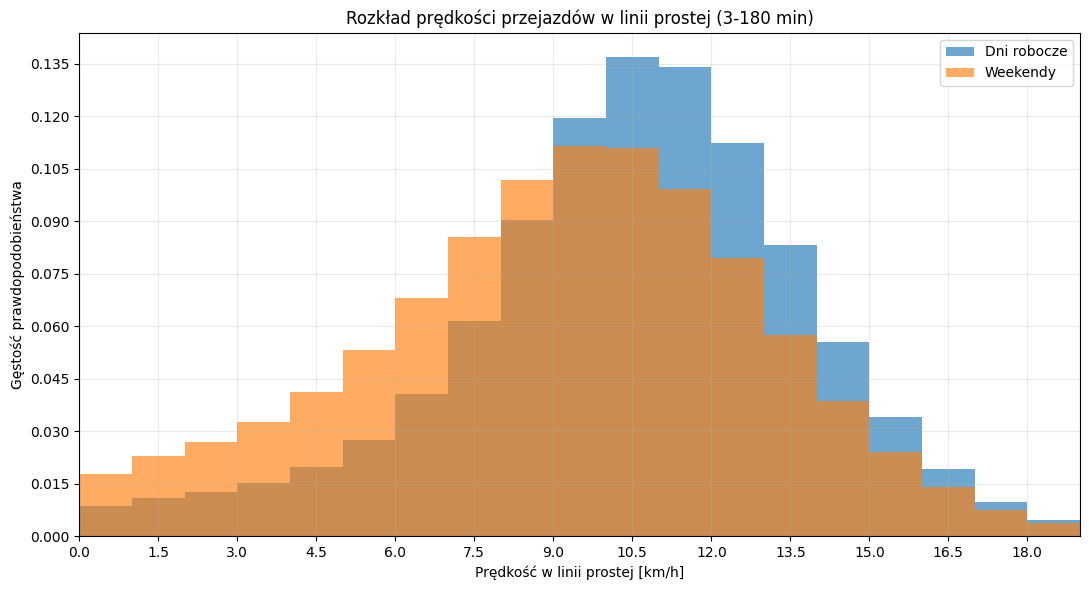

In [22]:
# ---------- Speed distribution for rides within the selected duration range ----------

speed_distribution_data = dur_dist_data.loc[
    dur_dist_data["total_duration_minutes"].between(lower_limit, upper_limit)
    & dur_dist_data["speed_km_per_h"].notna()
    & np.isfinite(dur_dist_data["speed_km_per_h"])
    & (dur_dist_data["speed_km_per_h"] > 0)
].copy()

speed_weekdays = speed_distribution_data[
    speed_distribution_data["start_day_of_week"].isin(
        ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
    )
]

speed_weekends = speed_distribution_data[
    speed_distribution_data["start_day_of_week"].isin(["Saturday", "Sunday"])
]

print(
    f"Liczba przejazdów w zakresie {lower_limit}-{upper_limit} min "
    f"z policzoną prędkością: {len(speed_distribution_data)}"
)

display(
    speed_distribution_data["speed_km_per_h"].describe(
        percentiles=[0.05, 0.5, 0.9, 0.95, 0.99, 0.995]
    )
)

speed_plot_upper_limit = np.ceil(
    speed_distribution_data["speed_km_per_h"].quantile(0.995)
)

speed_hist_upper_limit = np.ceil(speed_distribution_data["speed_km_per_h"].max())
speed_bins = np.arange(0, speed_hist_upper_limit + 1, 1)

plt.figure(figsize=(11, 6))

plt.hist(
    speed_weekdays["speed_km_per_h"],
    bins=speed_bins,
    density=True,
    alpha=0.65,
    color="#1F77B4",
    label="Dni robocze"
)

plt.hist(
    speed_weekends["speed_km_per_h"],
    bins=speed_bins,
    density=True,
    alpha=0.65,
    color="#FF7F0E",
    label="Weekendy"
)

plt.xlabel("Prędkość w linii prostej [km/h]")
plt.ylabel("Gęstość prawdopodobieństwa")
plt.title(
    f"Rozkład prędkości przejazdów w linii prostej ({lower_limit}-{upper_limit} min)"
)

plt.xlim(0, speed_plot_upper_limit)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(15))
plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(12))

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


a = 1.5
Number of bins: 24
First bin edges: [0.00527694 0.00791541 0.01187312 0.01780968 0.02671452]
Last bin edges: [17.54718795 26.32078193 39.4811729  59.22175935 68.40017186]

a = 1.75
Number of bins: 17
First bin edges: [0.00527694 0.00923465 0.01616064 0.02828111 0.04949195]
Last bin edges: [ 7.61863171 13.33260549 23.3320596  40.83110431 68.40017186]

a = 2
Number of bins: 14
First bin edges: [0.00527694 0.01055388 0.02110777 0.04221554 0.08443108]
Last bin edges: [ 5.40358893 10.80717787 21.61435573 43.22871146 68.40017186]


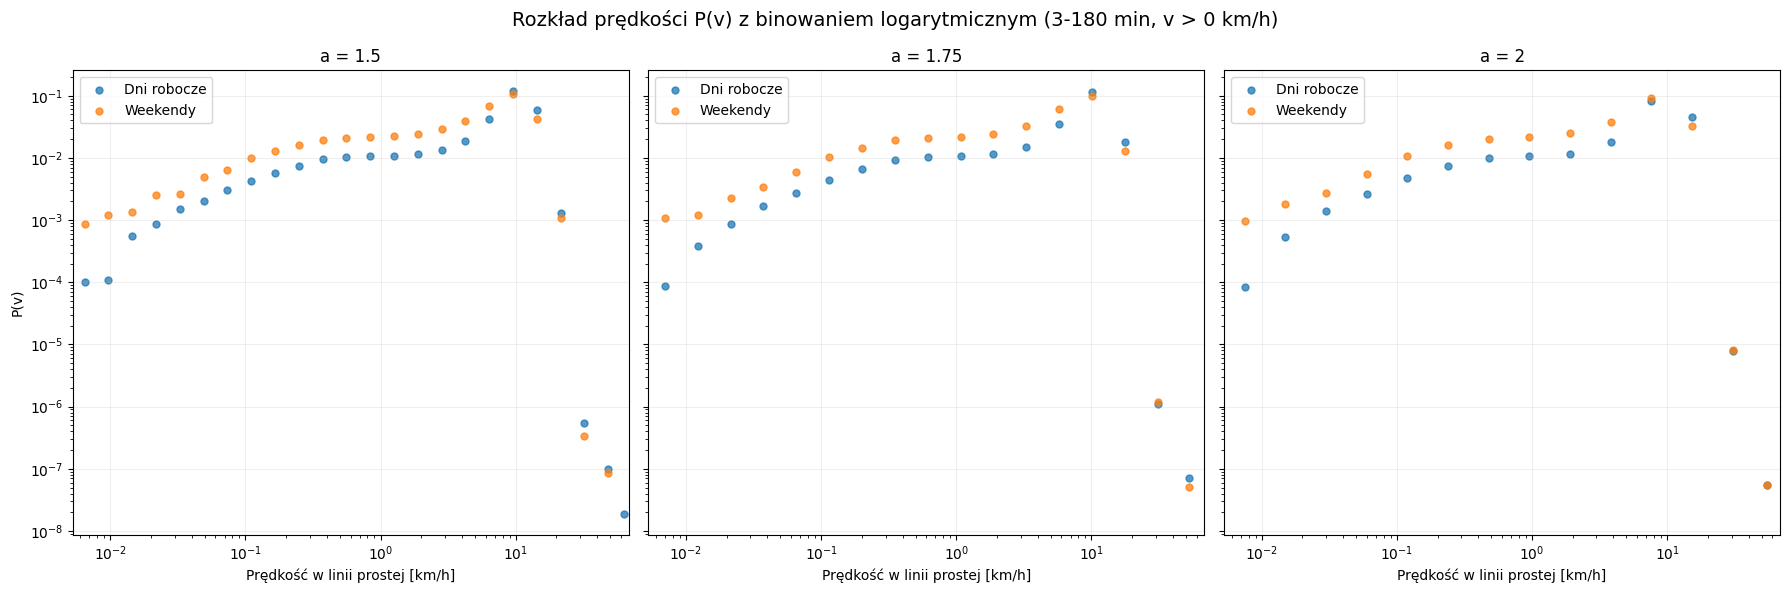

In [23]:
# ---------- Logarithmic speed distribution ----------

speed_values_weekdays = speed_weekdays["speed_km_per_h"]
speed_values_weekends = speed_weekends["speed_km_per_h"]

min_speed = speed_distribution_data["speed_km_per_h"].min()
max_speed = speed_distribution_data["speed_km_per_h"].max()


def make_speed_log_bin_edges(min_value, max_value, a):
    bin_edges = [min_value]

    while bin_edges[-1] < max_value:
        next_edge = bin_edges[-1] * a
        bin_edges.append(min(next_edge, max_value))

    return np.array(bin_edges)


def speed_log_binning(data, bin_edges):
    counts, edges = np.histogram(data, bins=bin_edges)
    widths = edges[1:] - edges[:-1]
    probability_density = counts / (len(data) * widths)
    bin_centers = np.sqrt(edges[:-1] * edges[1:])
    mask = probability_density > 0

    return (
        bin_centers[mask],
        probability_density[mask],
        counts[mask],
        edges
    )


speed_a_values = [1.5, 1.75, 2]
speed_results = {}

for a_value in speed_a_values:
    speed_bin_edges = make_speed_log_bin_edges(
        min_speed,
        max_speed,
        a_value
    )

    x_speed_weekdays, p_speed_weekdays, n_speed_weekdays, edges = speed_log_binning(
        speed_values_weekdays,
        speed_bin_edges
    )

    x_speed_weekends, p_speed_weekends, n_speed_weekends, edges = speed_log_binning(
        speed_values_weekends,
        speed_bin_edges
    )

    speed_results[a_value] = {
        "weekdays": {
            "x": x_speed_weekdays,
            "p": p_speed_weekdays,
            "n": n_speed_weekdays
        },
        "weekends": {
            "x": x_speed_weekends,
            "p": p_speed_weekends,
            "n": n_speed_weekends
        },
        "bin_edges": speed_bin_edges
    }

    print(f"\na = {a_value}")
    print("Number of bins:", len(speed_bin_edges) - 1)
    print("First bin edges:", speed_bin_edges[:5])
    print("Last bin edges:", speed_bin_edges[-5:])


# ---------- Plotting logarithmic speed probability density ----------

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

colors = {
    "Dni robocze": "#1F77B4",
    "Weekendy": "#FF7F0E"
}

for ax, a_value in zip(axes, speed_a_values):
    ax.scatter(
        speed_results[a_value]["weekdays"]["x"],
        speed_results[a_value]["weekdays"]["p"],
        s=25,
        alpha=0.75,
        color=colors["Dni robocze"],
        label="Dni robocze"
    )

    ax.scatter(
        speed_results[a_value]["weekends"]["x"],
        speed_results[a_value]["weekends"]["p"],
        s=25,
        alpha=0.75,
        color=colors["Weekendy"],
        label="Weekendy"
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(min_speed, max_speed)

    ax.set_xlabel("Prędkość w linii prostej [km/h]")
    ax.set_title(f"a = {a_value}")

    ax.grid(True, axis="y", alpha=0.2, which="major")
    ax.grid(True, axis="x", alpha=0.2, which="major")
    ax.legend()

axes[0].set_ylabel("P(v)")

fig.suptitle(
    f"Rozkład prędkości P(v) z binowaniem logarytmicznym "
    f"({lower_limit}-{upper_limit} min, v > 0 km/h)",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [24]:
# ---------- Rides with speed close to 10^-2 km/h ----------

station_columns = ["trip_id", "start_station_name", "end_station_name"]

slow_rides_10_plus_2 = (
    speed_distribution_data.loc[
        speed_distribution_data["speed_km_per_h"].between(39, 40),
        [
            "trip_id",
            "start_date",
            "end_date",
            "total_duration_minutes",
            "straight_line_distance_km",
            "speed_km_per_h"
        ]
    ]
    .merge(
        pd.read_parquet(DATA_FILE, columns=station_columns),
        on="trip_id",
        how="left"
    )
    .sort_values("speed_km_per_h")
)

display(
    slow_rides_10_plus_2[
        [
            "trip_id",
            "start_date",
            "end_date",
            "start_station_name",
            "end_station_name",
            "total_duration_minutes",
            "straight_line_distance_km",
            "speed_km_per_h"
        ]
    ]
)

,trip_id,start_date,end_date,start_station_name,end_station_name,total_duration_minutes,straight_line_distance_km,speed_km_per_h
0,138593898,2024-04-15 15:43:00,2024-04-15 15:46:00,"Michael Road, Walham Green","Flood Street, Chelsea",3.004850,1.954359,39.024093
1,153826780,2025-11-15 10:20:00,2025-11-15 10:25:00,"Ilchester Gardens, Bayswater","Colet Gardens, Hammersmith",4.467733,2.959367,39.743203


In [25]:
# ---------- Rides with speed close to 10^-2 km/h ----------

station_columns = ["trip_id", "start_station_name", "end_station_name"]

fast_rides_10_minus_2 = (
    speed_distribution_data.loc[
        speed_distribution_data["speed_km_per_h"].between(0.0095, 0.0105),
        [
            "trip_id",
            "start_date",
            "end_date",
            "total_duration_minutes",
            "straight_line_distance_km",
            "speed_km_per_h"
        ]
    ]
    .merge(
        pd.read_parquet(DATA_FILE, columns=station_columns),
        on="trip_id",
        how="left"
    )
    .sort_values("speed_km_per_h")
)

display(
    fast_rides_10_minus_2[
        [
            "trip_id",
            "start_date",
            "end_date",
            "start_station_name",
            "end_station_name",
            "total_duration_minutes",
            "straight_line_distance_km",
            "speed_km_per_h"
        ]
    ]
)

,trip_id,start_date,end_date,start_station_name,end_station_name,total_duration_minutes,straight_line_distance_km,speed_km_per_h
0,149824349,2025-06-26 20:46:00,2025-06-26 22:12:00,"Belvedere Road 1, South Bank","Belvedere Road 2, South Bank",86.465,0.013742,0.009536
